# Clipboard contour/surface plot notebook

Excel で `z=f(x,y)` テーブルをコピーし、いったん Python 変数に格納してから 3D surface + color contour を描く Notebook。

想定する表の並びは Modelica の `CombiTable2Ds` と同じで、左上セルはダミー、1 行目が `y` 軸、1 列目が `x` 軸、内部が `z` 値です。

## 使い方

1. Excel で表全体をコピーする。
2. 下の `capture_clipboard_table()` セルを実行して、クリップボード内容を `raw_clip_df` に保存する。
3. `raw_clip_df` を確認する。
4. `parse_combitable2ds_layout(raw_clip_df)` を実行する。
5. `plot_surface_with_contours(x, y, z)` を実行する。

必要なら最後のセルで PNG 保存もできます。

In [5]:
import datetime
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

plt.rcParams['figure.figsize'] = (10, 7)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.grid'] = True

print(datetime.datetime.now())
print("----- cell executed -----")

2026-10-01 06:30:55.080961
----- cell executed -----


In [6]:
def capture_clipboard_table(header=None):
    """Excel からコピーした表を一度 DataFrame 変数へ取り込む。"""
    df = pd.read_clipboard(header=header)
    return df

raw_clip_df = capture_clipboard_table(header=None)
raw_clip_df

print("clipboard cell range data has been read into python array")
print("--------------------")

def parse_combitable2ds_layout(df):
    """
    CombiTable2Ds 風の表を x, y, z に分解する。
    [0, 1:] = y 軸
    [1:, 0] = x 軸
    [1:, 1:] = z 値
    """
    work = df.copy()

    y = pd.to_numeric(work.iloc[0, 1:], errors='raise').to_numpy(dtype=float)
    x = pd.to_numeric(work.iloc[1:, 0], errors='raise').to_numpy(dtype=float)
    z = work.iloc[1:, 1:].apply(pd.to_numeric, errors='raise').to_numpy(dtype=float)

    if z.shape != (len(x), len(y)):
        raise ValueError(f'z shape {z.shape} does not match len(x), len(y) = {(len(x), len(y))}')

    return x, y, z

x, y, z = parse_combitable2ds_layout(raw_clip_df)
print('x shape =', x.shape)
print('y shape =', y.shape)
print('z shape =', z.shape)

print("--------------------")

def preview_axes_and_range(x, y, z):
    print(f'x: min={x.min()}, max={x.max()}, n={len(x)}')
    print(f'y: min={y.min()}, max={y.max()}, n={len(y)}')
    print(f'z: min={np.nanmin(z)}, max={np.nanmax(z)}')
    print('x first5 =', x[:5])
    print('y first5 =', y[:5])

preview_axes_and_range(x, y, z)

print("data ready to plot")
print("--------------------")

print(datetime.datetime.now())
print("----- cell executed -----")

clipboard cell range data has been read into python array
--------------------
x shape = (58,)
y shape = (10,)
z shape = (58, 10)
--------------------
x: min=-20.0, max=220.0, n=58
y: min=-60.0, max=60.0, n=10
z: min=0.0, max=0.2
x first5 = [-20.    0.  150.  150.2 150.4]
y first5 = [-60. -40. -20. -10.   0.]
data ready to plot
--------------------
2026-10-01 06:30:56.368647
----- cell executed -----


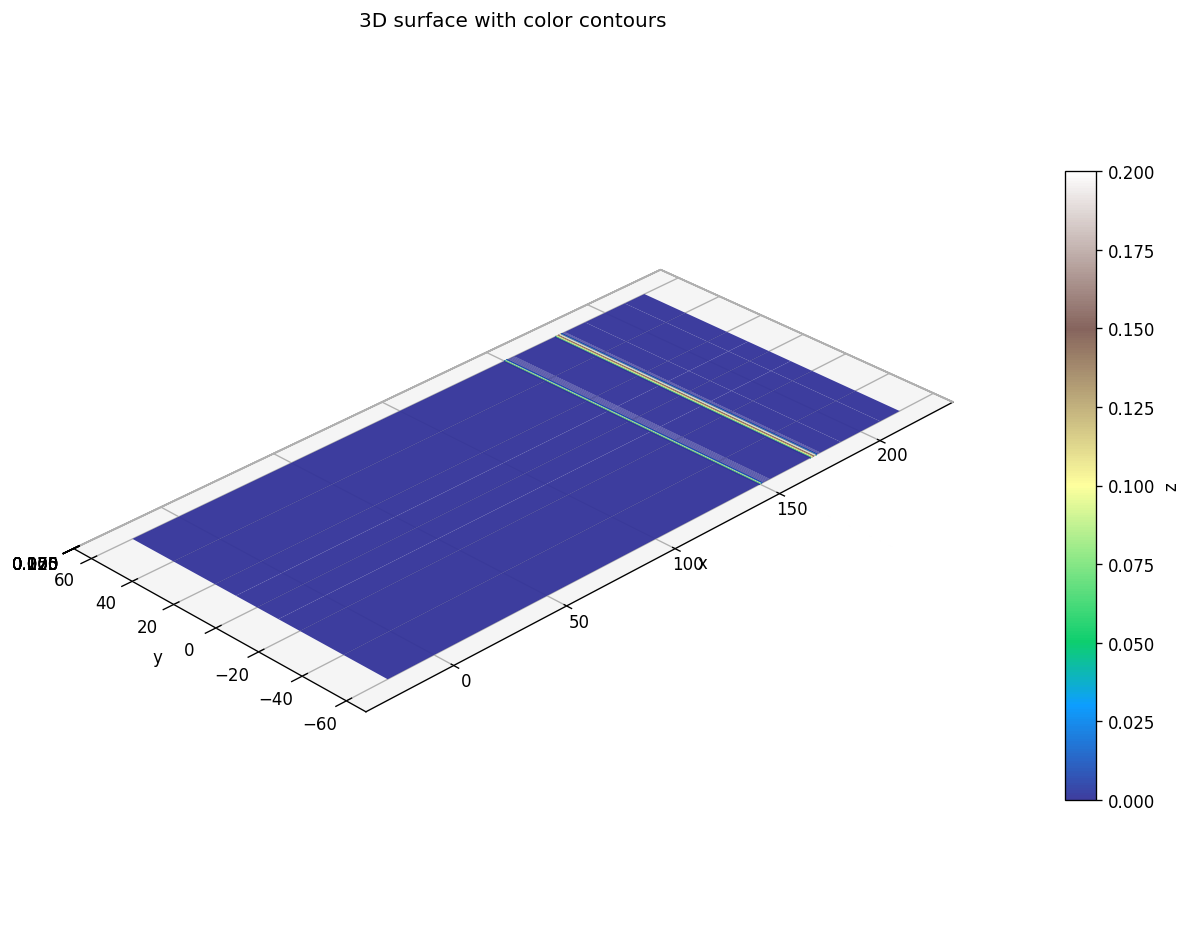

2026-10-01 06:31:10.618501
----- cell executed -----


In [7]:
def plot_surface_with_contours(x, y, z, cmap='viridis', n_contours=15, elev=30, azim=-135):
    X, Y = np.meshgrid(x, y, indexing='ij')

    fig = plt.figure(figsize=(11, 8))
    ax = fig.add_subplot(111, projection='3d')

    surf = ax.plot_surface(
        X, Y, z,
        cmap=cmap,
        linewidth=0.15,
        edgecolor='none',
        antialiased=True,
        alpha=0.95
    )

    zmin = np.nanmin(z)
    contours = ax.contour(
        X, Y, z,
        levels=n_contours,
        zdir='z',
        offset=zmin,
        cmap=cmap,
        linewidths=1.0
    )

    cbar = fig.colorbar(surf, ax=ax, shrink=0.7, pad=0.08)
    cbar.set_label('z')

    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_zlabel('z')
    ax.set_title('3D surface with color contours')
    ax.view_init(elev=elev, azim=azim)
    ax.set_zlim(zmin, np.nanmax(z))

    xrange = max(np.ptp(x), 1e-12)
    yrange = max(np.ptp(y), 1e-12)
    zrange = max(np.ptp(z), 1e-12)
    ax.set_box_aspect((xrange, yrange, 0.5 * zrange))

    plt.tight_layout()
    return fig, ax

fig, ax = plot_surface_with_contours(x, y, z, cmap='terrain', n_contours=20)
plt.show()

print(datetime.datetime.now())
print("----- cell executed -----")

In [ ]:
# 必要なら視点やカラーマップを変えて再描画
fig, ax = plot_surface_with_contours(x, y, z, cmap='viridis', n_contours=25, elev=35, azim=-120)
plt.show()

print(datetime.datetime.now())
print("----- cell executed -----")

In [ ]:
# PNG 保存したい場合
fig, ax = plot_surface_with_contours(x, y, z, cmap='terrain', n_contours=20)
fig.savefig('clipboard_surface_contour.png', dpi=220, bbox_inches='tight')
plt.show()

print(datetime.datetime.now())
print("----- cell executed -----")